In [240]:
import pickle
import pandas as pd
import seaborn as sns


# Load the data
norm = 'networknorm'
num_nodes_values = range(1000, 5001, 1000)
density_values = [0.001, 0.005, 0.01]

dfs = []
for num_nodes in num_nodes_values:
    for density in density_values:
        with open(f'scalar_{norm}_{density}_{num_nodes}.pkl', 'rb') as f:
            scalar_raw = pickle.load(f)

        df = pd.DataFrame.from_dict(scalar_raw).T
        df = df.dropna(axis=1)
        dfs.append(df)

merged_df = pd.concat(dfs)

In [241]:
merged_df

,Average Local Efficiency,Average Shortest Path Length,Center,Diameter,Global Efficiency,Periphery,Radius,Entropy of Degree Distribution,Max Degree,Self-Loops,...,Skewness Degree,Kurtosis Degree,Average Locality Index,Variation Locality Index,Average Subgraph Centrality,Variation Subgraph Centrality,Skewness Clustering Coefficient,Kurtosis Clustering Coefficient,Skewness Locality Index,Kurtosis Locality Index
ba_graph_0.001_1000_0,0.032147,0.004101,0.001000,0.007007,0.260424,0.175000,0.004004,0.250319,0.100000,0.000,...,9.124895,132.058860,0.002058,0.000048,0.0,0.0,NaN,NaN,NaN,NaN
er_graph_0.001_1000_0,0.000000,0.160085,0.032258,0.377049,0.170165,0.048387,0.196721,0.185669,0.005000,0.000,...,0.885765,0.400832,0.000000,0.000000,0.0,0.0,NaN,NaN,NaN,NaN
ws_graph_0.001_1000_0,0.000000,0.039249,0.002294,0.106774,0.044444,0.003440,0.053961,0.175997,0.006000,0.000,...,0.818257,0.992593,0.000000,0.000000,0.0,0.0,NaN,NaN,NaN,NaN
dgm_graph_0.001_1000_0,0.878879,0.003550,0.002740,0.006399,0.277368,0.109589,0.003656,0.137266,0.116895,0.000,...,11.306377,155.981303,0.047327,0.001266,0.0,0.0,NaN,NaN,NaN,NaN
sf_graph_0.001_1000_0,0.175306,0.002937,0.018000,0.007007,0.368543,0.030000,0.004004,0.206712,0.523000,0.002,...,23.481554,629.119111,0.003963,0.000510,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ba_graph_0.01_5000_99,0.129478,0.000500,0.000200,0.000600,0.420479,0.999800,0.000400,0.471971,0.119600,0.000,...,5.097995,35.540082,0.008952,0.000087,0.0,0.0,1.041433,2.085721,5.299919,39.125720
er_graph_0.01_5000_99,0.013609,0.000518,0.999200,0.000800,0.405285,0.000800,0.000600,0.394871,0.015800,0.000,...,0.184987,0.086354,0.004832,0.000002,0.0,0.0,0.256400,0.184076,0.189391,-0.048842
ws_graph_0.01_5000_99,0.168538,0.000612,1.000000,0.000800,0.337878,1.000000,0.000800,0.293883,0.007200,0.000,...,0.188613,0.024026,0.045731,0.000379,0.0,0.0,0.721301,0.671923,0.660759,0.576731
dgm_graph_0.01_5000_99,0.879472,0.001320,0.007313,0.002438,0.246920,0.080439,0.001524,0.118233,0.078001,0.000,...,18.320700,426.446363,0.045085,0.001297,0.0,0.0,-1.001180,-0.542406,0.646761,-0.779011


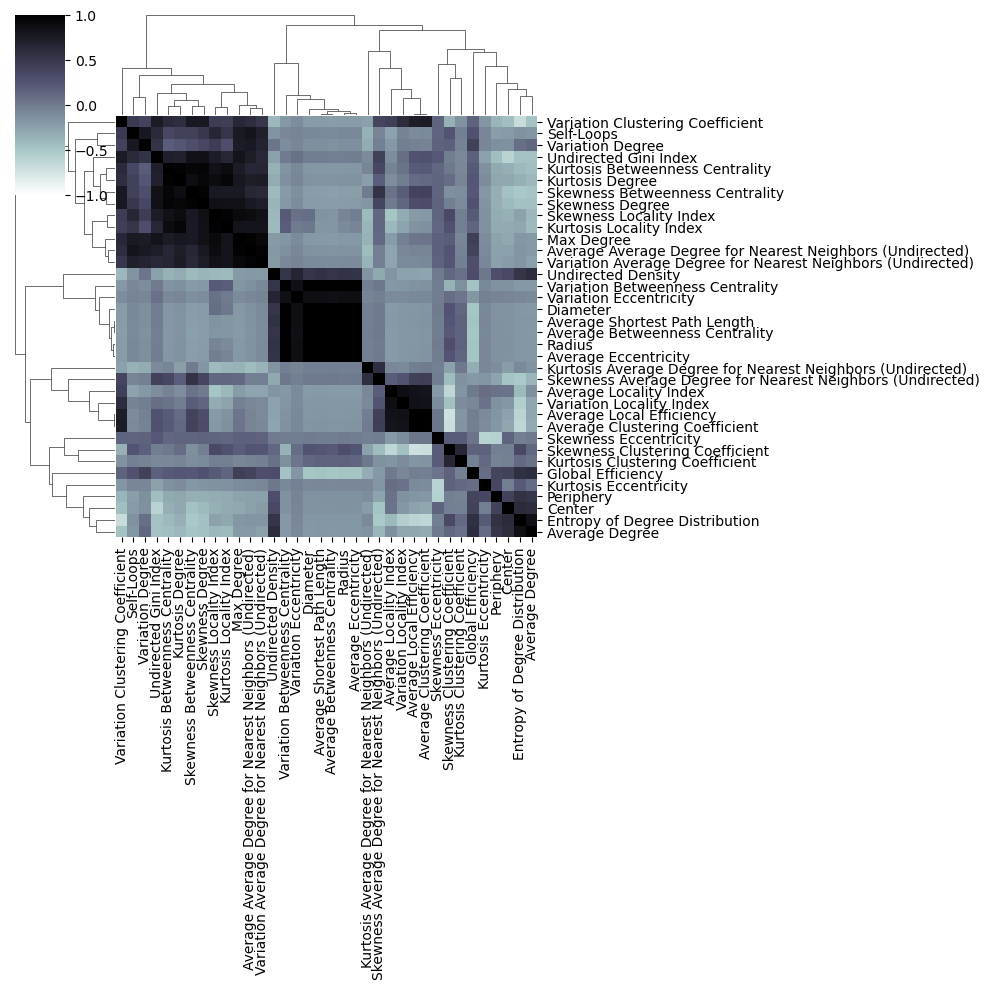

In [242]:
merged_df_corr = merged_df.corr()
merged_df_corr.dropna(axis=1, how='all', inplace=True)
merged_df_corr.dropna(axis=0, how='all', inplace=True)
sns.clustermap(merged_df_corr,xticklabels=True, yticklabels=True, cmap='bone_r', vmin=-1, vmax=1)

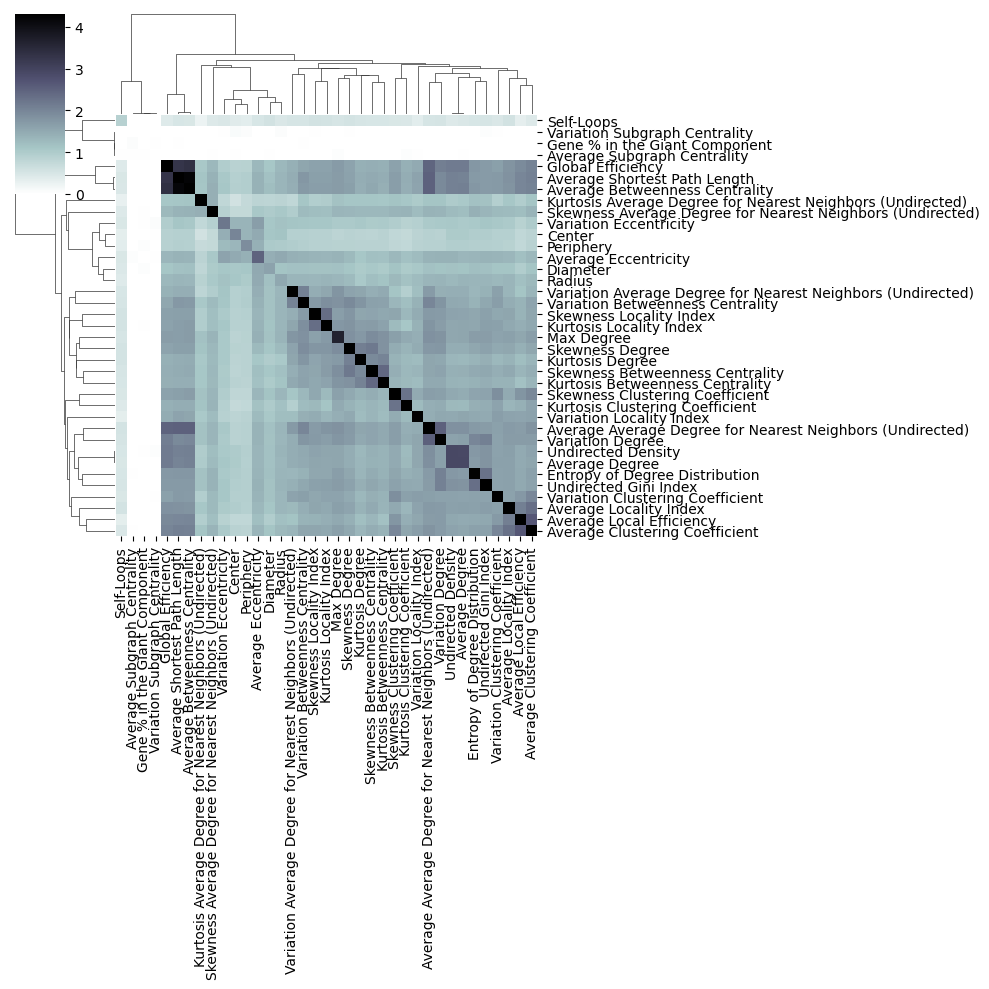

In [232]:
from sklearn.feature_selection import mutual_info_regression
import pickle
import pandas as pd

norm = 'networknorm'
num_nodes_values = range(1000, 5001, 1000)
density_values = [0.001, 0.005, 0.01]

dfs = []
for num_nodes in num_nodes_values:
    for density in density_values:
        with open(f'scalar_{norm}_{density}_{num_nodes}.pkl', 'rb') as f:
            scalar_raw = pickle.load(f)

        df = pd.DataFrame.from_dict(scalar_raw).T
        df = df.dropna(axis=1)
        dfs.append(df)

merged_df = pd.concat(dfs)

merged_df_corr = pd.DataFrame(index=df.columns, columns=df.columns)
for i in df.columns:
    for j in df.columns:
        merged_df_corr.loc[i,j] = mutual_info_regression(df[[i]], df[j])[0]


sns.clustermap(merged_df_corr.astype(float),xticklabels=True, yticklabels=True, cmap='bone_r')

# Edges

In [149]:
with open('edges_0.01_5000.pkl', 'rb') as f:
    edges = pickle.load(f)

type_density_nodes_edges = []
for name, num_edges in edges.items():
    net_type, _, density, num_nodes, _ = name.split('_')
    type_density_nodes_edges.append([net_type, density, num_nodes, num_edges])

In [158]:
df.edges.max()

126143

edges    Axes(0.125,0.11;0.775x0.77)
dtype: object

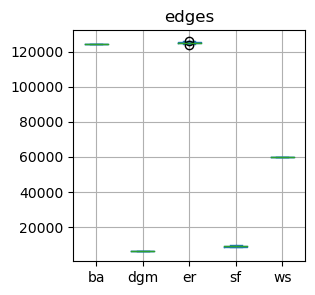

In [168]:
df = pd.DataFrame.from_records(type_density_nodes_edges, columns=['type', 'density', 'nodes', 'edges'], coerce_float=True)
df.plot.box(by='type', column=['edges'], grid=True, figsize=(3,3))

In [175]:
(5000**2)/2*0.01

125000.0

In [188]:
df

,type,density,nodes,edges
0,ba,0.01,5000,124375
1,er,0.01,5000,125192
2,ws,0.01,5000,60000
3,dgm,0.01,5000,6561
4,sf,0.01,5000,8541
...,...,...,...,...
495,ba,0.01,5000,124375
496,er,0.01,5000,125406
497,ws,0.01,5000,60000
498,dgm,0.01,5000,6561


nodes    Axes(0.125,0.11;0.775x0.77)
dtype: object

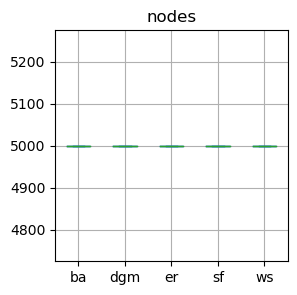

In [176]:
df.nodes = df.nodes.astype(int)
df.plot.box(by='type', column=['nodes'], grid=True, figsize=(3,3))

density    Axes(0.125,0.11;0.775x0.77)
dtype: object

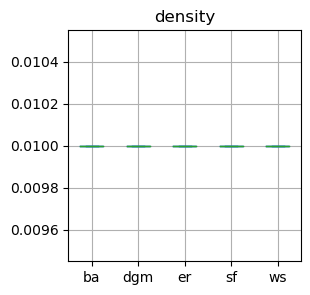

In [185]:
df.density = df.density.astype(float)
df.plot.box(by='type', column=['density'], grid=True, figsize=(3,3))